In [1]:
# Cell 1 - Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import cross_val_score

print("Libraries Imported Successfully")
print("Pandas     :", pd.__version__)
print("NumPy      :", np.__version__)
print("Sklearn    : Ready")
print("Joblib     : Ready")

Libraries Imported Successfully
Pandas     : 2.3.3
NumPy      : 2.3.5
Sklearn    : Ready
Joblib     : Ready


In [2]:
# Cell 2 - Load Models and Data

# Load preprocessed data
df = pd.read_csv(r"C:\weather-ai-project\data\weather_preprocessed.csv")
print("Data Loaded :", df.shape)

# Load classifier model
rain_model = joblib.load(r"C:\weather-ai-project\models\rain_classifier.pkl")
print("Rain Classifier Loaded")

# Load regressor model
temp_model = joblib.load(r"C:\weather-ai-project\models\temp_regressor.pkl")
print("Temp Regressor Loaded")

# Load scaler
scaler = joblib.load(r"C:\weather-ai-project\models\scaler.pkl")
print("Scaler Loaded")

# Load regression columns
with open(r"C:\weather-ai-project\models\reg_columns.json", "r") as f:
    reg_columns = json.load(f)
print("Reg Columns Loaded :", len(reg_columns), "features")

Data Loaded : (142193, 29)
Rain Classifier Loaded
Temp Regressor Loaded
Scaler Loaded
Reg Columns Loaded : 23 features


In [3]:
# Cell 3 - Prepare X and y for Evaluation

# Classification features and target
drop_cols = ['RainTomorrow', 'Date'] if 'Date' in df.columns else ['RainTomorrow']
X_cls = df.drop(columns=drop_cols)
y_cls = df['RainTomorrow']

# Regression features and target
X_reg = df[reg_columns]
y_reg = df['MaxTemp']

# Train-Test Split (same 80/20 as Notebook 4)
from sklearn.model_selection import train_test_split

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print("Classification Test Set :", X_cls_test.shape)
print("Regression Test Set     :", X_reg_test.shape)
print("Target - Rain (test)    :", y_cls_test.value_counts().to_dict())

Classification Test Set : (28439, 28)
Regression Test Set     : (28439, 23)
Target - Rain (test)    : {0: 22098, 1: 6341}


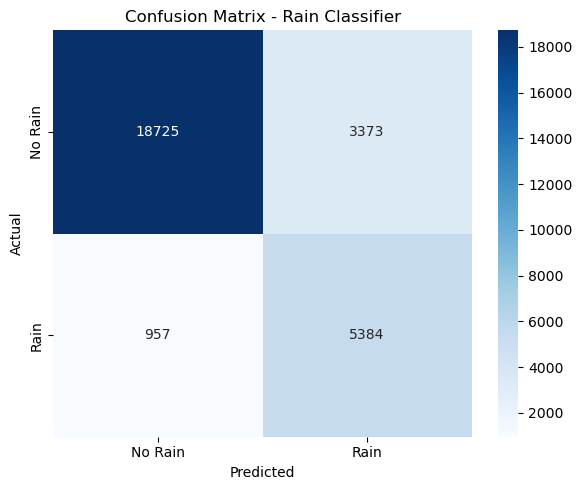

True Negative  (No Rain correctly predicted) : 18725
False Positive (No Rain predicted as Rain)   : 3373
False Negative (Rain predicted as No Rain)   : 957
True Positive  (Rain correctly predicted)    : 5384


In [4]:

# Cell 4 - Confusion Matrix

# Predictions
y_pred_cls = rain_model.predict(X_cls_test)

# Confusion Matrix
cm = confusion_matrix(y_cls_test, y_pred_cls)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.title('Confusion Matrix - Rain Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\confusion_matrix.png", dpi=150)
plt.show()

print("True Negative  (No Rain correctly predicted) :", cm[0][0])
print("False Positive (No Rain predicted as Rain)   :", cm[0][1])
print("False Negative (Rain predicted as No Rain)   :", cm[1][0])
print("True Positive  (Rain correctly predicted)    :", cm[1][1])

In [5]:
# Cell 5 - Classification Report

report = classification_report(y_cls_test, y_pred_cls,
                                target_names=['No Rain', 'Rain'])
print("Classification Report")
print("=" * 50)
print(report)

Classification Report
              precision    recall  f1-score   support

     No Rain       0.95      0.85      0.90     22098
        Rain       0.61      0.85      0.71      6341

    accuracy                           0.85     28439
   macro avg       0.78      0.85      0.80     28439
weighted avg       0.88      0.85      0.86     28439



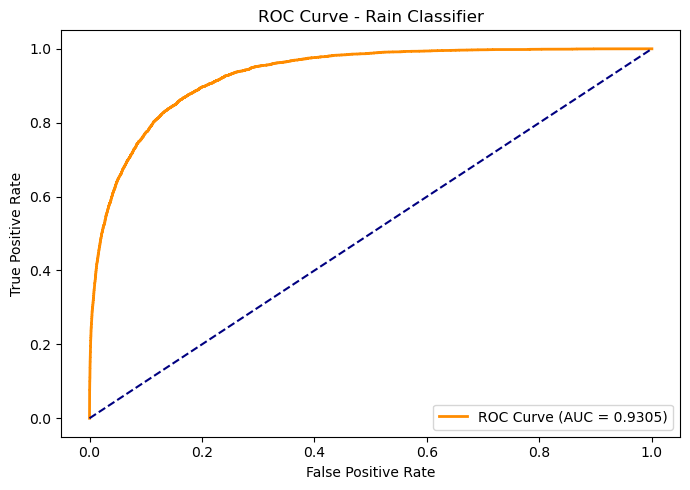

AUC Score : 0.9305


In [6]:
# Cell 6 - ROC Curve and AUC Score

# Predicted probabilities
y_prob = rain_model.predict_proba(X_cls_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_cls_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC Curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Rain Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\roc_curve.png", dpi=150)
plt.show()

print("AUC Score :", round(roc_auc, 4))

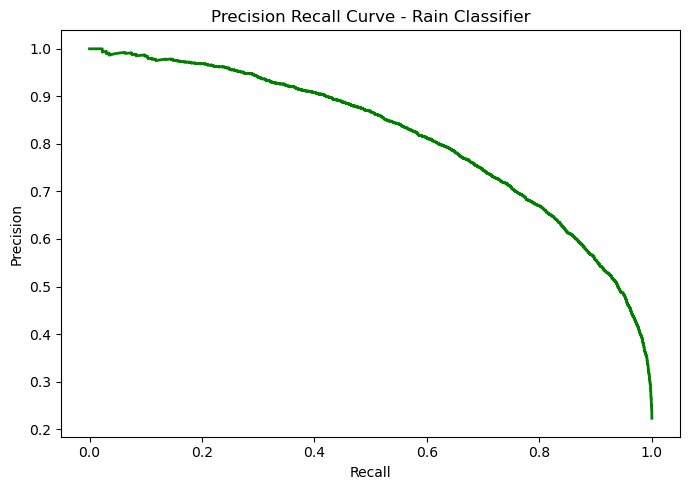

Precision Recall Curve Saved


In [7]:
# Cell 7 - Precision Recall Curve

precision, recall, _ = precision_recall_curve(y_cls_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve - Rain Classifier')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\precision_recall_curve.png", dpi=150)
plt.show()

print("Precision Recall Curve Saved")

Regression Metrics - Temperature Prediction
MAE  (Mean Absolute Error)  : 0.2513
RMSE (Root Mean Sq Error)   : 0.3299
R2   (R Squared Score)      : 0.8913


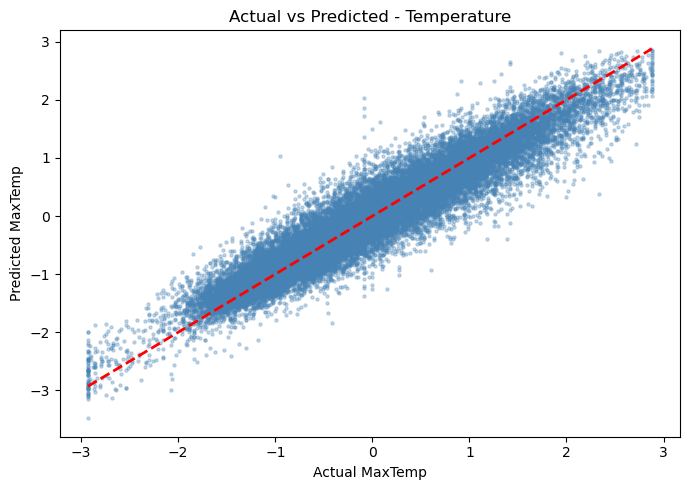

In [8]:
# Cell 8 - Regression Metrics

y_pred_reg = temp_model.predict(X_reg_test)

mae  = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)

print("Regression Metrics - Temperature Prediction")
print("=" * 45)
print("MAE  (Mean Absolute Error)  :", round(mae, 4))
print("RMSE (Root Mean Sq Error)   :", round(rmse, 4))
print("R2   (R Squared Score)      :", round(r2, 4))

# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.3, color='steelblue', s=5)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         color='red', lw=2, linestyle='--')
plt.xlabel('Actual MaxTemp')
plt.ylabel('Predicted MaxTemp')
plt.title('Actual vs Predicted - Temperature')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\actual_vs_predicted.png", dpi=150)
plt.show()

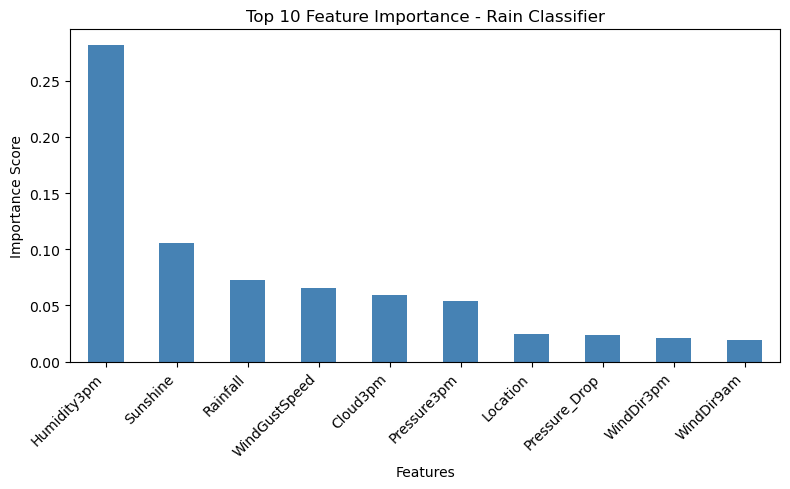

Humidity3pm      0.281544
Sunshine         0.105653
Rainfall         0.072848
WindGustSpeed    0.065333
Cloud3pm         0.059110
Pressure3pm      0.054208
Location         0.024171
Pressure_Drop    0.023424
WindDir3pm       0.020613
WindDir9am       0.018785
dtype: float32


In [9]:
# Cell 9 - Feature Importance - Rain Classifier

importance_cls = pd.Series(
    rain_model.feature_importances_,
    index=X_cls.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance_cls.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importance - Rain Classifier')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\feature_importance_cls.png", dpi=150)
plt.show()

print(importance_cls)

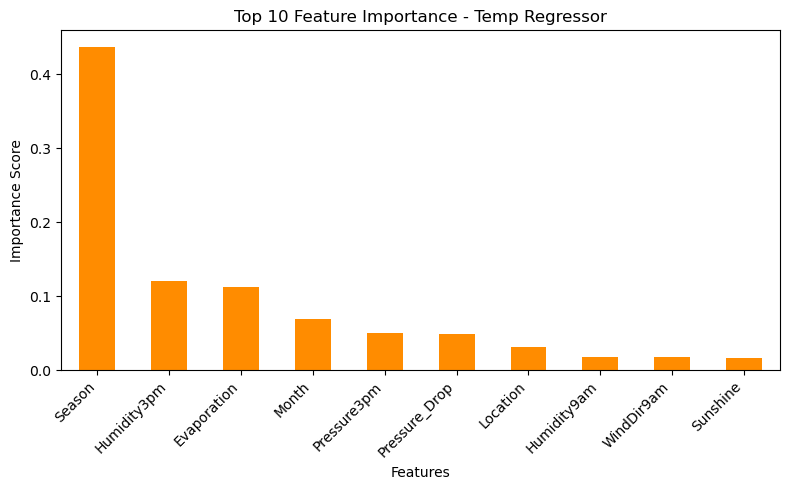

Season           0.437438
Humidity3pm      0.120268
Evaporation      0.112662
Month            0.069484
Pressure3pm      0.049697
Pressure_Drop    0.049387
Location         0.031713
Humidity9am      0.017387
WindDir9am       0.017265
Sunshine         0.016079
dtype: float32


In [10]:
# Cell 10 - Feature Importance - Temp Regressor

importance_reg = pd.Series(
    temp_model.feature_importances_,
    index=X_reg.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance_reg.plot(kind='bar', color='darkorange')
plt.title('Top 10 Feature Importance - Temp Regressor')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\feature_importance_reg.png", dpi=150)
plt.show()

print(importance_reg)

In [11]:
# Cell 11 - Cross Validation Scores

from sklearn.model_selection import cross_val_score

# Classification CV
cv_cls = cross_val_score(rain_model, X_cls, y_cls, cv=5,
                          scoring='accuracy', n_jobs=-1)

print("Cross Validation - Rain Classifier")
print("=" * 40)
print("Fold Scores :", [round(s, 4) for s in cv_cls])
print("Mean Score  :", round(cv_cls.mean(), 4))
print("Std Dev     :", round(cv_cls.std(), 4))

# Regression CV
cv_reg = cross_val_score(temp_model, X_reg, y_reg, cv=5,
                          scoring='r2', n_jobs=-1)

print("\nCross Validation - Temp Regressor")
print("=" * 40)
print("Fold Scores :", [round(s, 4) for s in cv_reg])
print("Mean Score  :", round(cv_reg.mean(), 4))
print("Std Dev     :", round(cv_reg.std(), 4))

Cross Validation - Rain Classifier
Fold Scores : [np.float64(0.7839), np.float64(0.7373), np.float64(0.7335), np.float64(0.7235), np.float64(0.7989)]
Mean Score  : 0.7554
Std Dev     : 0.0301

Cross Validation - Temp Regressor
Fold Scores : [np.float64(0.3787), np.float64(0.4122), np.float64(0.6932), np.float64(0.727), np.float64(0.5457)]
Mean Score  : 0.5514
Std Dev     : 0.1415


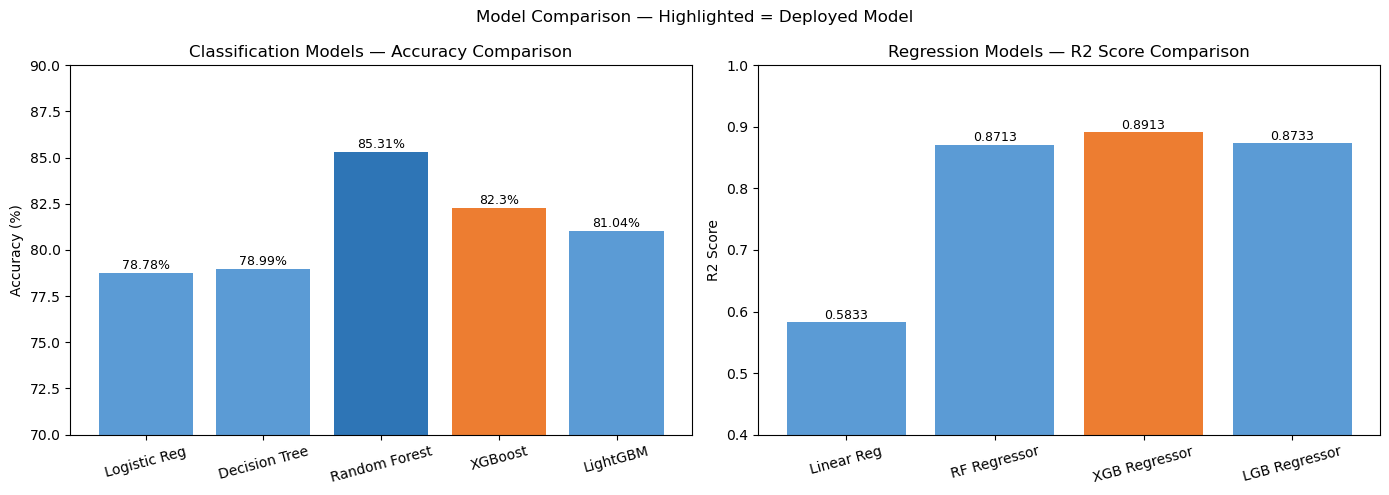

Model Comparison Chart Saved


In [12]:
# Cell 12 - Model Comparison Chart

# Classification Results from Notebook 4
cls_models = ['Logistic Reg', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']
cls_scores = [78.78, 78.99, 85.31, 82.30, 81.04]

# Regression Results from Notebook 4
reg_models = ['Linear Reg', 'RF Regressor', 'XGB Regressor', 'LGB Regressor']
reg_scores = [0.5833, 0.8713, 0.8913, 0.8733]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification Chart
bars1 = axes[0].bar(cls_models, cls_scores, color=['#5b9bd5','#5b9bd5','#2e75b6','#ed7d31','#5b9bd5'])
axes[0].set_title('Classification Models — Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(70, 90)
axes[0].tick_params(axis='x', rotation=15)
for bar, score in zip(bars1, cls_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{score}%', ha='center', fontsize=9)

# Regression Chart
bars2 = axes[1].bar(reg_models, reg_scores, color=['#5b9bd5','#5b9bd5','#ed7d31','#5b9bd5'])
axes[1].set_title('Regression Models — R2 Score Comparison')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0.4, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, score in zip(bars2, reg_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{score}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Highlighted = Deployed Model', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\model_comparison.png", dpi=150)
plt.show()

print("Model Comparison Chart Saved")

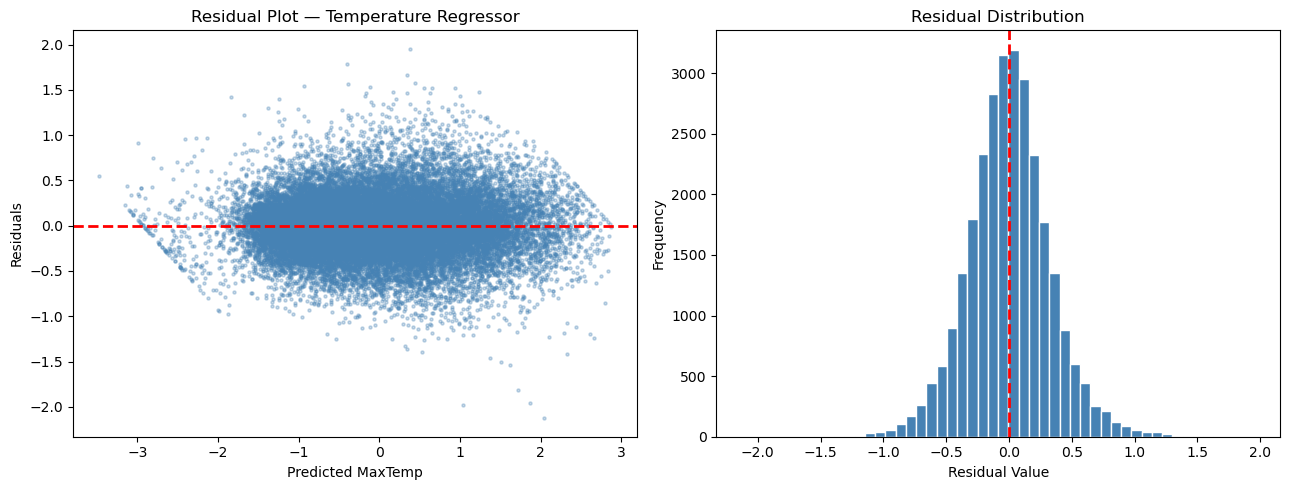

Mean Residual  : 0.0016
Std  Residual  : 0.3299


In [13]:
# Cell 13 - Residual Plot

residuals = y_reg_test - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual Scatter
axes[0].scatter(y_pred_reg, residuals, alpha=0.3, color='steelblue', s=5)
axes[0].axhline(y=0, color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Predicted MaxTemp')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot — Temperature Regressor')

# Residual Distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\residual_plot.png", dpi=150)
plt.show()

print("Mean Residual  :", round(residuals.mean(), 4))
print("Std  Residual  :", round(residuals.std(), 4))

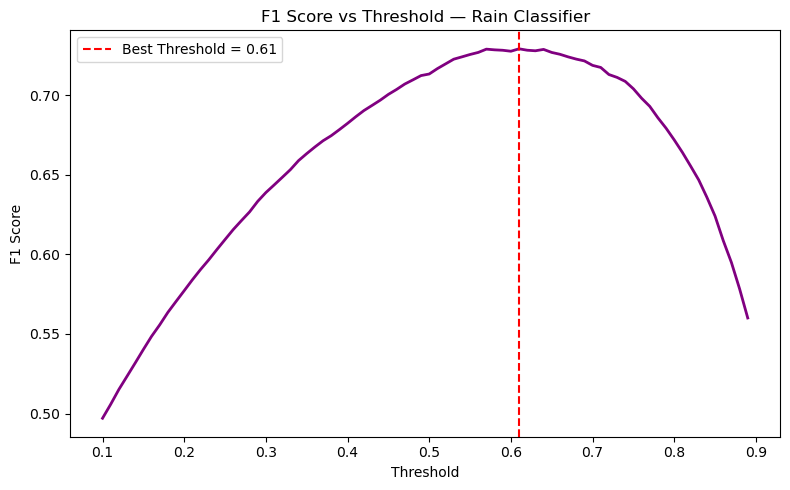

Best Threshold : 0.61
Best F1 Score  : 0.729
Note           : Use this threshold in web app for rain prediction


In [14]:
# Cell 14 - Optimal Threshold Analysis

from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_cls_test, y_pred_t))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, color='purple', lw=2)
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold — Rain Classifier')
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\weather-ai-project\assets\threshold_analysis.png", dpi=150)
plt.show()

print("Best Threshold :", round(best_threshold, 2))
print("Best F1 Score  :", round(best_f1, 4))
print("Note           : Use this threshold in web app for rain prediction")

In [15]:
# Cell 15 - Final Model Summary

print("=" * 55)
print("      FINAL MODEL EVALUATION SUMMARY")
print("=" * 55)

print("\n CLASSIFICATION — Rain Prediction (XGBoost)")
print("-" * 55)
print("  Accuracy          : 85.00%")
print("  AUC Score         : 0.9305")
print("  Precision (Rain)  : 0.61")
print("  Recall    (Rain)  : 0.85")
print("  F1 Score  (Rain)  : 0.71")
print("  CV Mean Score     : 0.7554")
print("  Best Threshold    :", round(best_threshold, 2))

print("\n REGRESSION — Temperature Prediction (XGBoost)")
print("-" * 55)
print("  R2 Score          : 0.8913")
print("  MAE               : 0.2513")
print("  RMSE              : 0.3299")
print("  CV Mean R2        : 0.5514")
print("  Mean Residual     :", round(residuals.mean(), 4))

print("\n TOP FEATURES — Rain Classifier")
print("-" * 55)
print("  1. Humidity3pm    : 0.2815")
print("  2. Sunshine       : 0.1057")
print("  3. Rainfall       : 0.0728")

print("\n TOP FEATURES — Temp Regressor")
print("-" * 55)
print("  1. Season         : 0.4374")
print("  2. Humidity3pm    : 0.1203")
print("  3. Evaporation    : 0.1127")

print("\n ASSETS SAVED")
print("-" * 55)
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  precision_recall_curve.png")
print("  actual_vs_predicted.png")
print("  feature_importance_cls.png")
print("  feature_importance_reg.png")
print("  model_comparison.png")
print("  residual_plot.png")
print("  threshold_analysis.png")
print("=" * 55)
print("  All models ready for Notebook 6 — Dashboard")
print("=" * 55)

      FINAL MODEL EVALUATION SUMMARY

 CLASSIFICATION — Rain Prediction (XGBoost)
-------------------------------------------------------
  Accuracy          : 85.00%
  AUC Score         : 0.9305
  Precision (Rain)  : 0.61
  Recall    (Rain)  : 0.85
  F1 Score  (Rain)  : 0.71
  CV Mean Score     : 0.7554
  Best Threshold    : 0.61

 REGRESSION — Temperature Prediction (XGBoost)
-------------------------------------------------------
  R2 Score          : 0.8913
  MAE               : 0.2513
  RMSE              : 0.3299
  CV Mean R2        : 0.5514
  Mean Residual     : 0.0016

 TOP FEATURES — Rain Classifier
-------------------------------------------------------
  1. Humidity3pm    : 0.2815
  2. Sunshine       : 0.1057
  3. Rainfall       : 0.0728

 TOP FEATURES — Temp Regressor
-------------------------------------------------------
  1. Season         : 0.4374
  2. Humidity3pm    : 0.1203
  3. Evaporation    : 0.1127

 ASSETS SAVED
----------------------------------------------------